# Banking Customer Portfolio & Exposure Analytics
## 1. Objective

In this notebook, I explore the financial columns, compare deposit and lending medians, review important correlations, and analyse the recorded `risk_weighting` field.

I keep high-value records, use correlation only as a measure of association, and do not treat risk weighting as default probability.

## 2. Load and Briefly Validate Processed Data

I load the cleaned file and check only the columns needed for this analysis.

In [1]:
# Import the packages used for data, charts, paths, and notebook output.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="deep")

In [2]:
# Find the project folder and set the input and output paths.
cwd = Path.cwd().resolve()
if (cwd / "data/processed/banking_customers_clean.csv").exists():
    project_root = cwd
else:
    project_root = cwd.parent
data_path = project_root / "data/processed/banking_customers_clean.csv"
figures_dir = project_root / "reports/figures/financial_exposure"
tables_dir = project_root / "reports/tables"
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Load the cleaned dataset.
df = pd.read_csv(data_path, parse_dates=["joined_bank"])
print(f"Loaded {len(df):,} records and {df.shape[1]} columns.")
display(df.head())

Loaded 3,000 records and 30 columns.


,client_id,name,age,location_id,joined_bank,banking_contact,nationality,occupation,fee_structure,loyalty_classification,estimated_income,superannuation_savings,amount_of_credit_cards,credit_card_balance,bank_loans,bank_deposits,checking_accounts,saving_accounts,foreign_currency_account,business_lending,properties_owned,risk_weighting,brid,genderid,iaid,join_year,join_month,join_month_name,join_decade,income_band
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,"75,384.77","17,677.95",1,484.54,"776,242.92","1,485,828.64","603,617.88","607,332.46","12,249.96","1,134,475.30",1,2,1,1,1,2019,5,May,2010,Low
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,"289,834.31","17,398.92",1,"2,256.88","1,270,615.43","641,482.79","229,521.37","344,635.16","61,162.31","2,000,526.10",1,3,2,1,2,2001,12,December,2000,Mid
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,"169,935.23","42,825.90",2,"4,568.74","1,052,715.84","1,033,401.59","652,674.69","203,054.35","79,071.78","548,137.58",1,3,3,2,3,2010,1,January,2010,Mid
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,"356,808.11","5,473.15",2,"4,205.00","121,195.06","1,048,157.49","1,048,157.49","234,685.02","57,513.65","1,148,402.29",0,4,4,1,4,2019,3,March,2010,High
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,"130,711.68","48,077.60",1,"3,779.49","1,048,301.95","487,782.53","446,644.25","128,351.45","30,012.14","1,674,412.12",0,3,1,2,5,2012,7,July,2010,Mid


In [4]:
# List the financial columns used in this notebook.
financial_columns = [
    "estimated_income",
    "superannuation_savings",
    "credit_card_balance",
    "bank_loans",
    "bank_deposits",
    "checking_accounts",
    "saving_accounts",
    "foreign_currency_account",
    "business_lending",
]

In [5]:
# List the financial columns used in this notebook.
segment_columns = [
    "income_band",
    "loyalty_classification",
    "fee_structure",
    "brid",
    "risk_weighting",
]
required_columns = financial_columns + segment_columns
missing_columns = [
    column for column in required_columns if column not in df.columns
]

In [6]:
# Run this step and check the result.
if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

In [7]:
# List the financial columns used in this notebook.
validation = pd.Series(
    {
        "rows": len(df),
        "financial_columns": len(financial_columns),
        "missing_financial_values": int(
            df[financial_columns].isna().sum().sum()
        ),
        "infinite_financial_values": int(
            np.isinf(df[financial_columns].to_numpy()).sum()
        ),
        "risk_weight_minimum": df["risk_weighting"].min(),
        "risk_weight_maximum": df["risk_weighting"].max(),
    }
)

In [8]:
# Display a short validation of the processed file.
display(validation.to_frame("result"))

,result
rows,3000
financial_columns,9
missing_financial_values,0
infinite_financial_values,0
risk_weight_minimum,1
risk_weight_maximum,5


In [9]:
# Create neutral BR labels and set the category orders.
df["banking_relationship"] = "BR " + df["brid"].astype(str)
income_order = ["Low", "Mid", "High"]
loyalty_order = ["Jade", "Silver", "Gold", "Platinum"]
fee_order = ["Low", "Mid", "High"]
risk_order = [1, 2, 3, 4, 5]
br_order = ["BR 1", "BR 2", "BR 3", "BR 4"]

## 3. Financial Distributions

I compare descriptive statistics, means, medians, histograms, and box plots for the nine financial columns.

In [10]:
# List the financial columns used in this notebook.
descriptive_statistics = df[financial_columns].describe().T
descriptive_statistics["median"] = df[financial_columns].median()
descriptive_statistics = descriptive_statistics[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]
]
display(descriptive_statistics)

,count,mean,median,std,min,25%,50%,75%,max
estimated_income,"3,000.00","171,305.03","142,313.48","111,935.81","15,919.48","82,906.60","142,313.48","242,290.30","522,330.26"
superannuation_savings,"3,000.00","25,531.60","22,357.36","16,259.95","1,482.03","12,513.77","22,357.36","35,464.74","75,963.90"
credit_card_balance,"3,000.00","3,176.21","2,560.81","2,497.09",1.17,"1,236.63","2,560.81","4,522.63","13,991.99"
bank_loans,"3,000.00","591,386.16","479,793.40","457,557.04",0.00,"239,628.14","479,793.40","825,813.04","2,667,556.66"
bank_deposits,"3,000.00","671,560.19","463,316.46","645,716.86",0.00,"204,400.38","463,316.46","942,754.63","3,890,598.08"
checking_accounts,"3,000.00","321,092.95","242,815.65","282,079.55",0.00,"119,947.53","242,815.65","434,874.94","1,969,923.08"
saving_accounts,"3,000.00","232,908.35","164,086.55","230,007.78",0.00,"74,794.40","164,086.55","315,575.00","1,724,118.36"
foreign_currency_account,"3,000.00","29,883.53","24,341.19","23,109.92",45.00,"11,916.54","24,341.19","41,966.39","124,704.87"
business_lending,"3,000.00","866,759.81","711,314.66","641,230.32",0.00,"374,825.14","711,314.66","1,185,110.07","3,825,961.94"


**Observation:** Every financial mean is above its median, showing right-skewed distributions. For example, bank deposits have a mean of **671,560.19** and a median of **463,316.46**. Currency units and valuation dates are not documented.

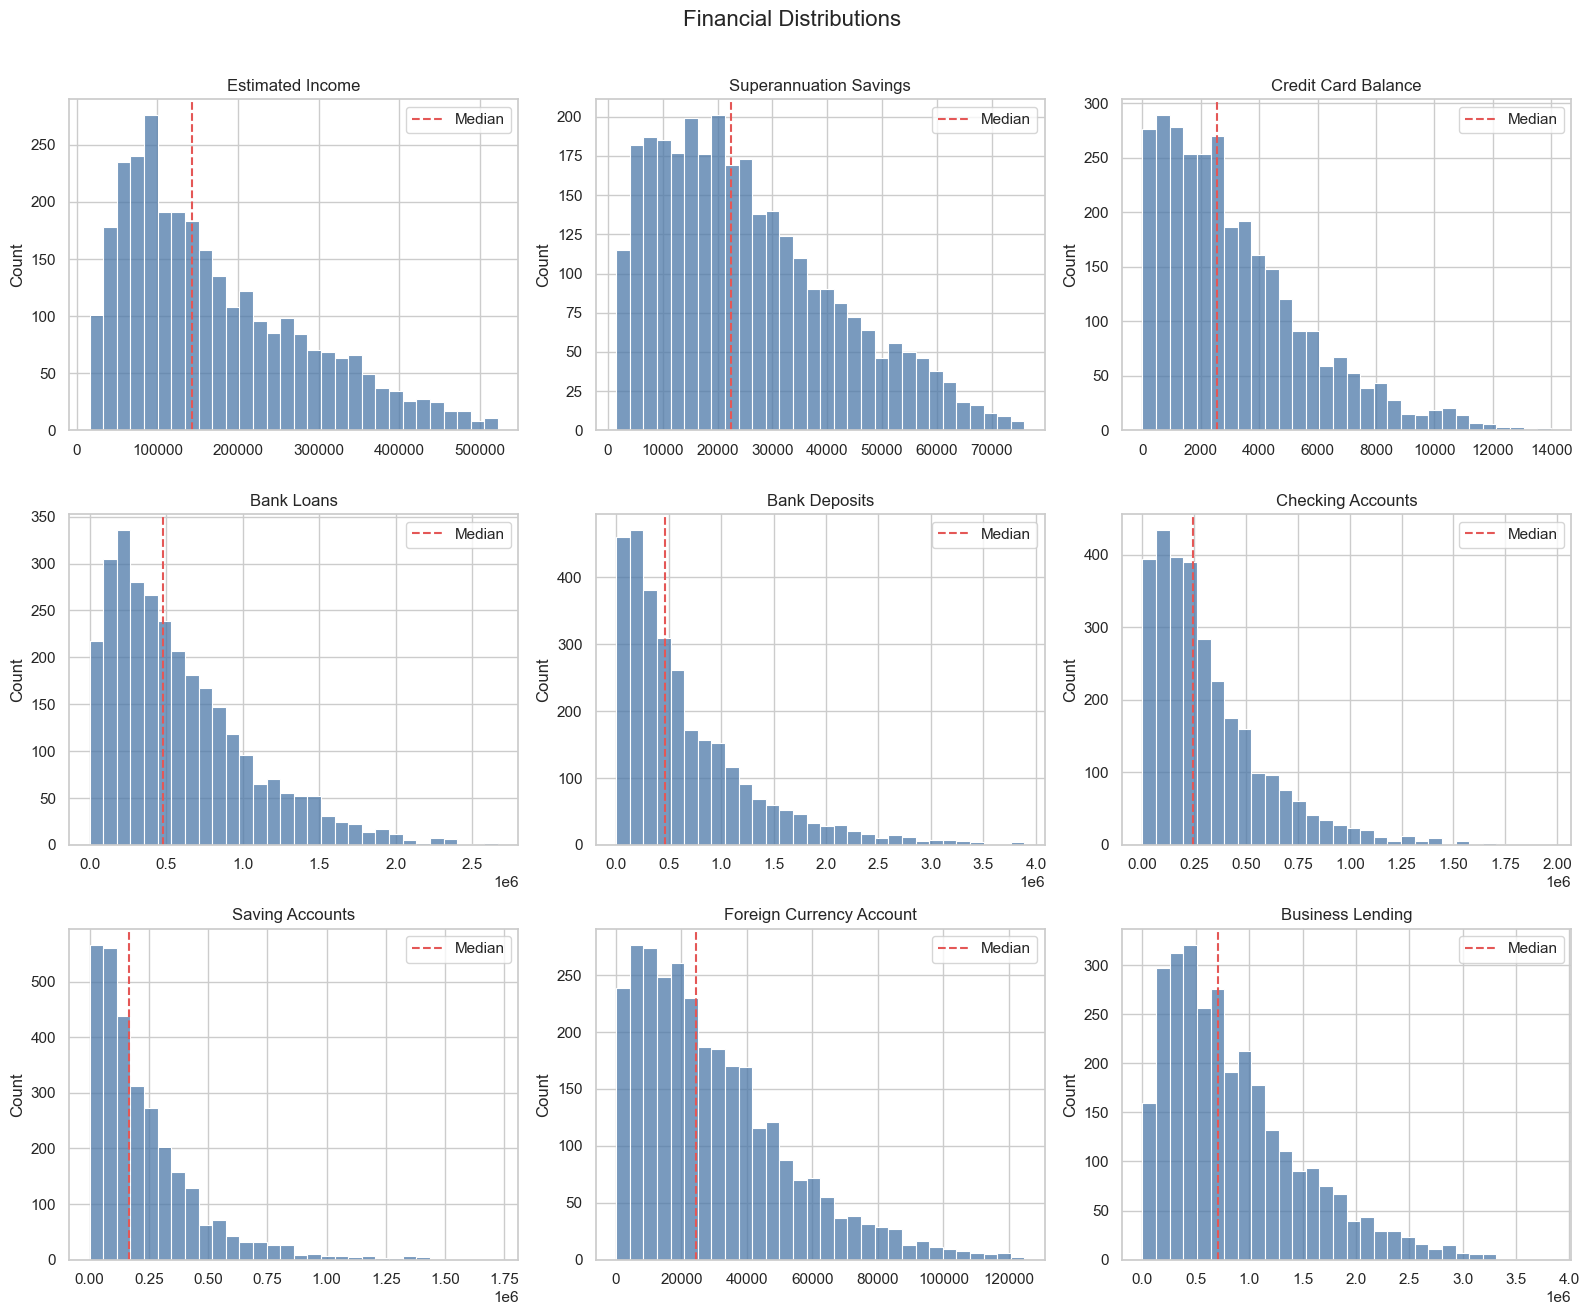

In [11]:
# List the financial columns used in this notebook.
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for index, column in enumerate(financial_columns):
    sns.histplot(
        data=df,
        x=column,
        bins=30,
        color="#4C78A8",
        edgecolor="white",
        ax=axes[index],
    )
    axes[index].axvline(
        df[column].median(),
        color="#E45756",
        linestyle="--",
        label="Median",
    )
    axes[index].set_title(column.replace("_", " ").title())
    axes[index].set_xlabel("")
    axes[index].legend()

fig.suptitle("Financial Distributions", fontsize=16, y=1.01)
plt.tight_layout()
fig.savefig(
    figures_dir / "financial_distributions.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 4. Skewness and Outlier Analysis

I calculate skewness and use the 1.5 ? IQR rule to flag possible outliers. These records are not removed automatically.

In [12]:
# Prepare the distribution-summary rows.
distribution_rows = []

In [13]:
# List the financial columns used in this notebook.
for column in financial_columns:
    values = df[column].dropna()
    first_quartile = values.quantile(0.25)
    third_quartile = values.quantile(0.75)
    iqr = third_quartile - first_quartile
    lower_boundary = first_quartile - 1.5 * iqr
    upper_boundary = third_quartile + 1.5 * iqr
    outlier_mask = (values < lower_boundary) | (values > upper_boundary)

    distribution_rows.append(
        {
            "financial_variable": column,
            "mean": values.mean(),
            "median": values.median(),
            "mean_minus_median": values.mean() - values.median(),
            "skewness": values.skew(),
            "q1": first_quartile,
            "q3": third_quartile,
            "iqr": iqr,
            "lower_iqr_boundary": lower_boundary,
            "upper_iqr_boundary": upper_boundary,
            "potential_outlier_count": int(outlier_mask.sum()),
            "potential_outlier_percentage": outlier_mask.mean() * 100,
        }
    )

In [14]:
# Prepare the distribution-summary rows.
financial_distribution_summary = pd.DataFrame(distribution_rows)
display(financial_distribution_summary)

,financial_variable,mean,median,mean_minus_median,skewness,q1,q3,iqr,lower_iqr_boundary,upper_iqr_boundary,potential_outlier_count,potential_outlier_percentage
0,estimated_income,"171,305.03","142,313.48","28,991.55",0.88,"82,906.60","242,290.30","159,383.71","-156,168.97","481,365.87",26,0.87
1,superannuation_savings,"25,531.60","22,357.36","3,174.24",0.71,"12,513.77","35,464.74","22,950.96","-21,912.67","69,891.19",19,0.63
2,credit_card_balance,"3,176.21","2,560.81",615.40,1.13,"1,236.63","4,522.63","3,286.00","-3,692.37","9,451.64",85,2.83
3,bank_loans,"591,386.16","479,793.40","111,592.76",1.18,"239,628.14","825,813.04","586,184.90","-639,649.21","1,705,090.39",85,2.83
4,bank_deposits,"671,560.19","463,316.46","208,243.73",1.71,"204,400.38","942,754.63","738,354.26","-903,131.01","2,050,286.01",149,4.97
5,checking_accounts,"321,092.95","242,815.65","78,277.29",1.73,"119,947.53","434,874.94","314,927.41","-352,443.58","907,266.05",138,4.60
6,saving_accounts,"232,908.35","164,086.55","68,821.80",2.19,"74,794.40","315,575.00","240,780.60","-286,376.49","676,745.90",155,5.17
7,foreign_currency_account,"29,883.53","24,341.19","5,542.34",1.12,"11,916.54","41,966.39","30,049.85","-33,158.23","87,041.17",79,2.63
8,business_lending,"866,759.81","711,314.66","155,445.15",1.15,"374,825.14","1,185,110.07","810,284.94","-840,602.27","2,400,537.48",93,3.10


**Observation:** Saving accounts is the most skewed variable (**2.193**) and has the highest IQR flag rate (**5.17%**, 155 records). These are potential outliers, not confirmed errors, so no values are removed.

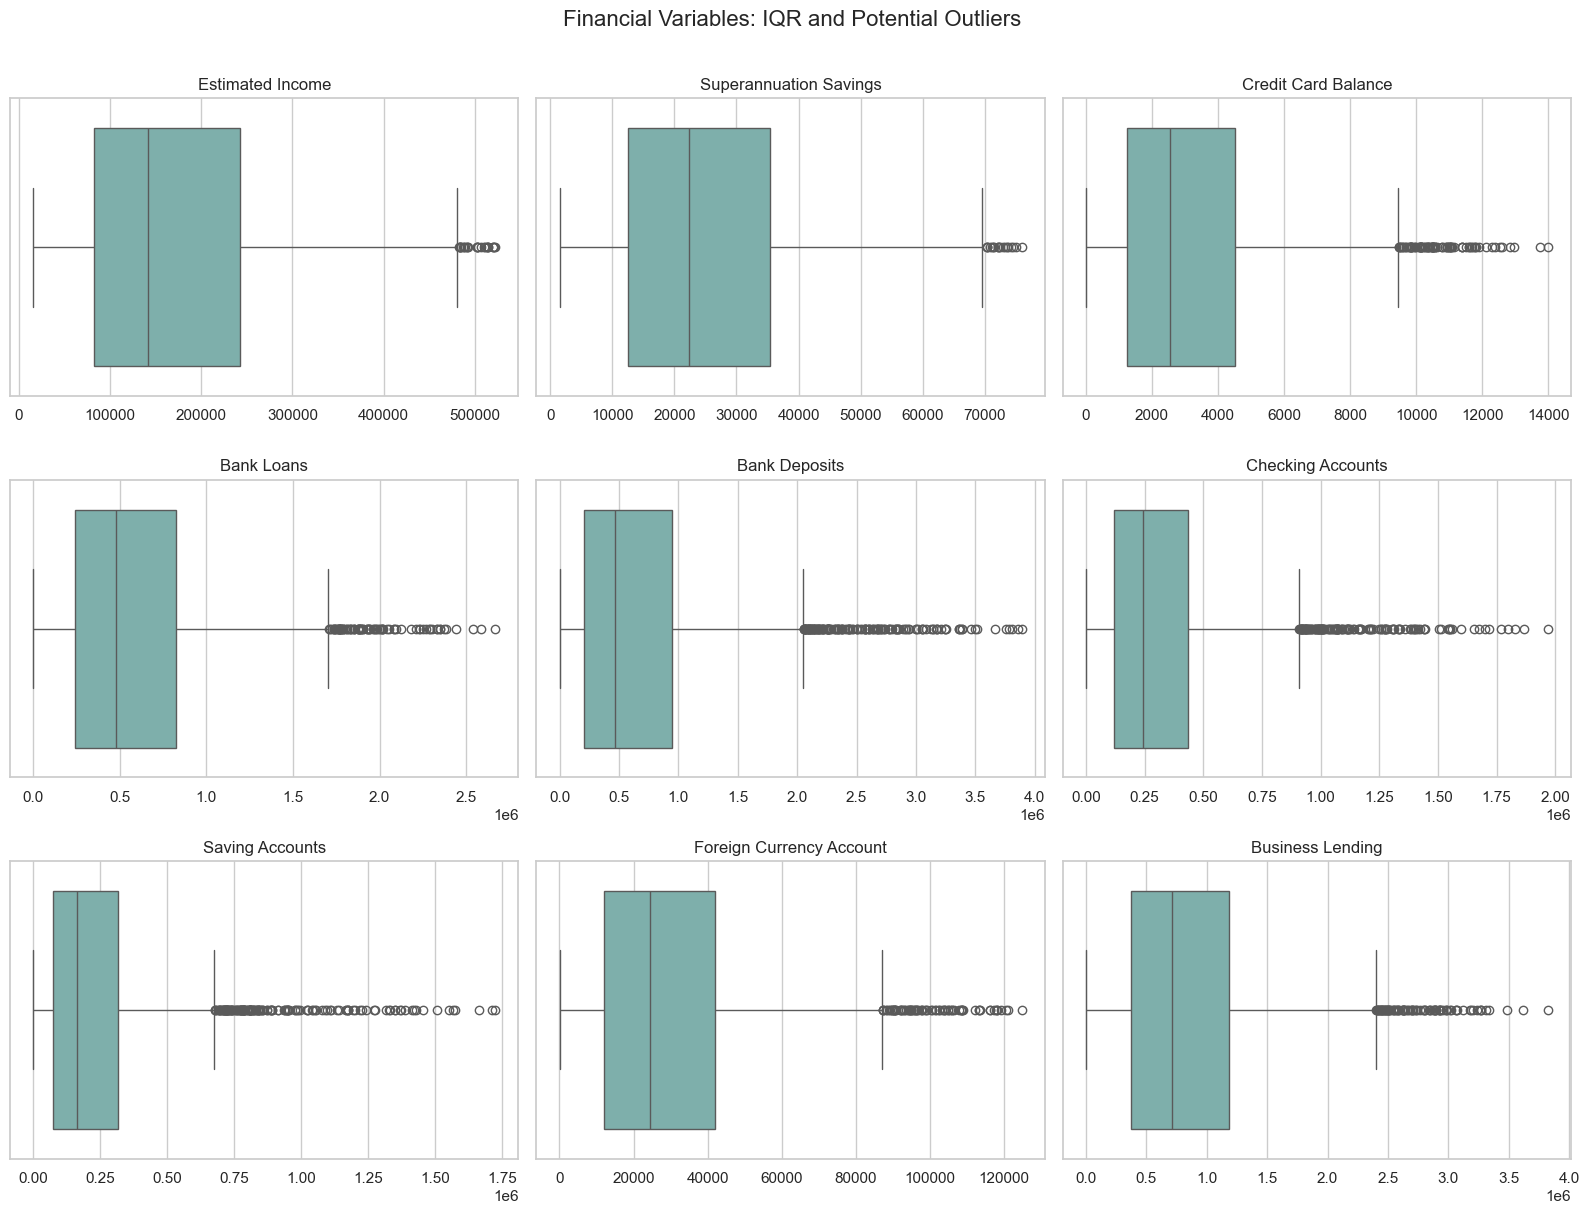

In [15]:
# List the financial columns used in this notebook.
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for index, column in enumerate(financial_columns):
    sns.boxplot(x=df[column], color="#76B7B2", ax=axes[index])
    axes[index].set_title(column.replace("_", " ").title())
    axes[index].set_xlabel("")
fig.suptitle(
    "Financial Variables: IQR and Potential Outliers", fontsize=16, y=1.01
)
plt.tight_layout()

fig.savefig(
    figures_dir / "financial_boxplots.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [16]:
# Display the financial distribution summary.
highly_skewed_columns = financial_distribution_summary.loc[
    financial_distribution_summary["skewness"].abs() > 1,
    "financial_variable",
].tolist()
print("Highly skewed variables:", highly_skewed_columns)

Highly skewed variables: ['credit_card_balance', 'bank_loans', 'bank_deposits', 'checking_accounts', 'saving_accounts', 'foreign_currency_account', 'business_lending']


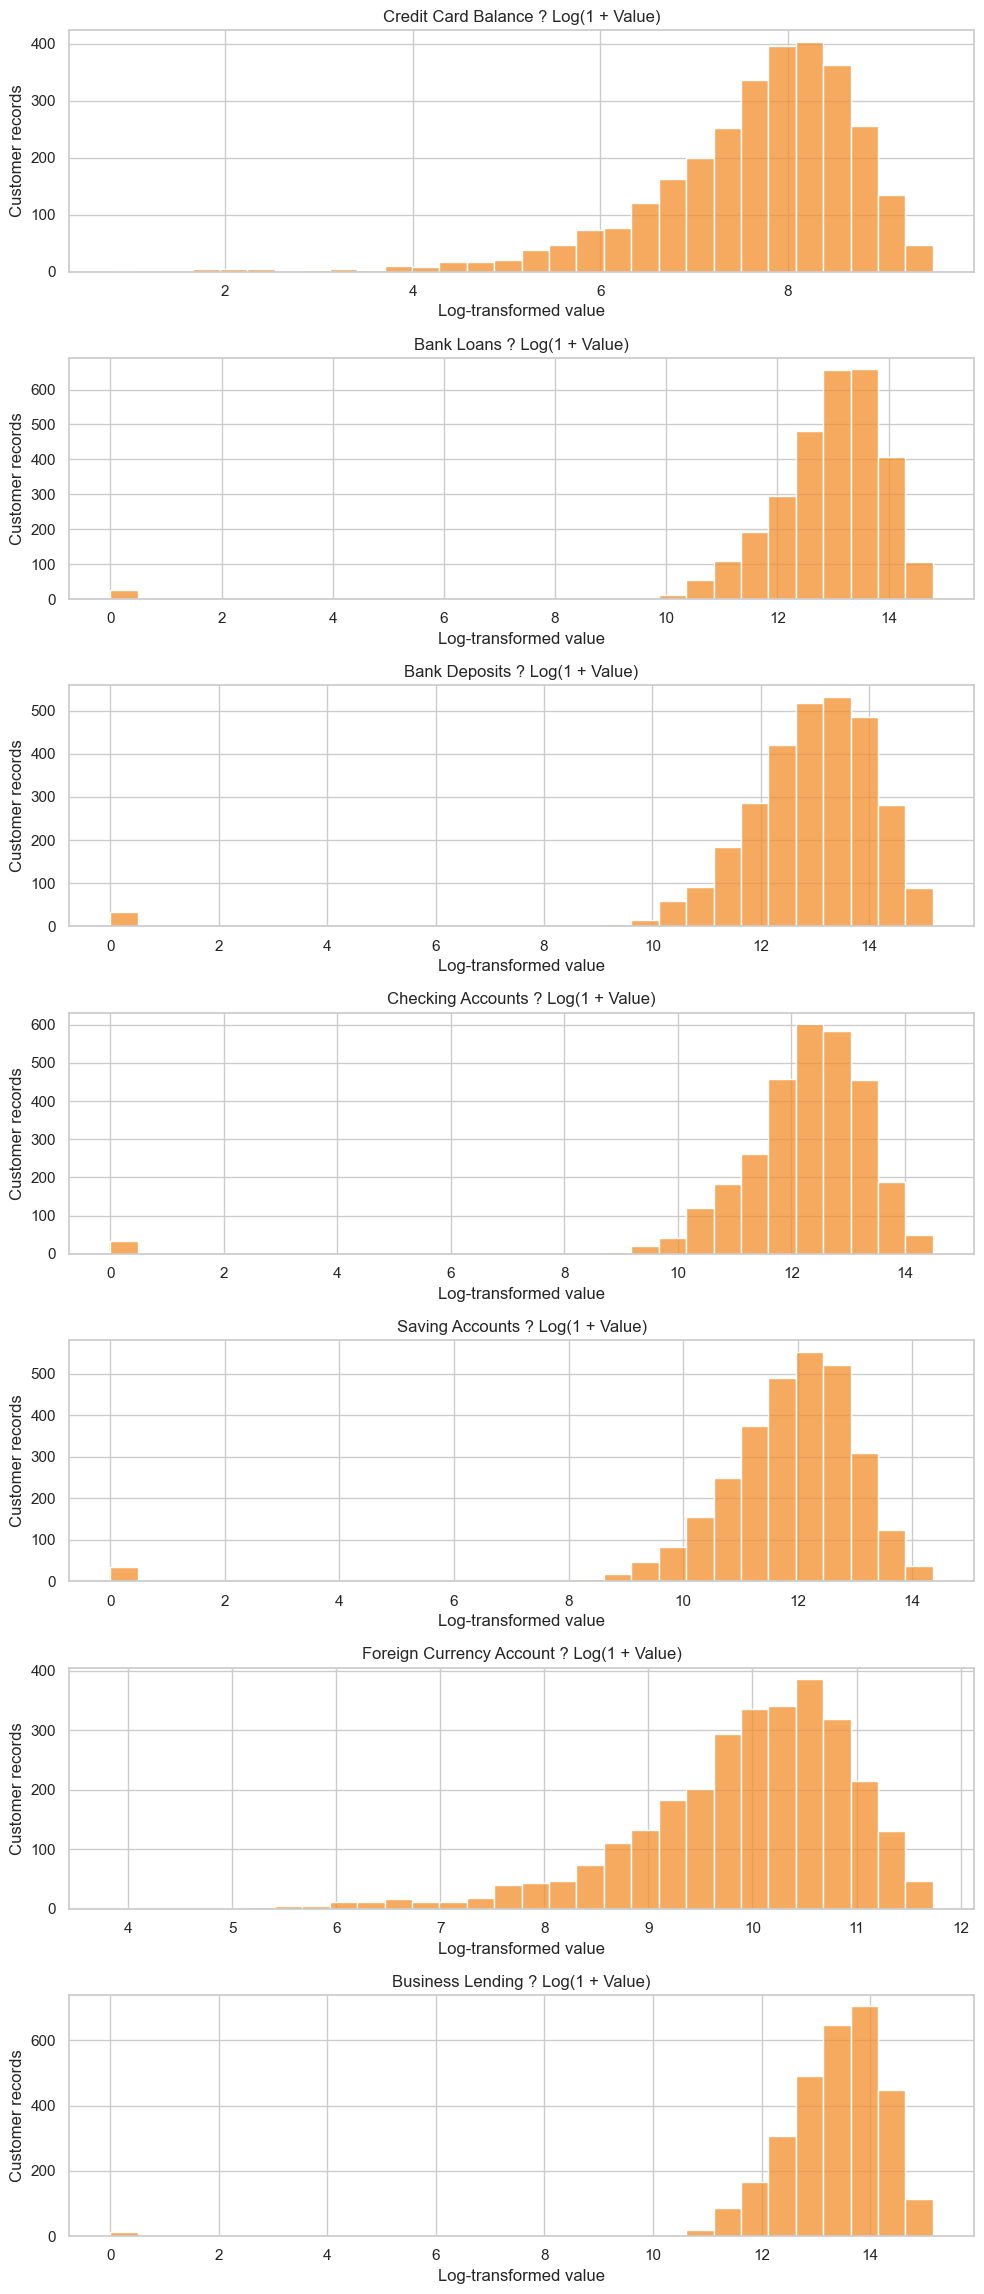

In [17]:
# Select financial columns with skewness above 1.
figure_count = len(highly_skewed_columns)
fig, axes = plt.subplots(
    figure_count,
    1,
    figsize=(10, 3.3 * figure_count),
)
axes = np.atleast_1d(axes)

for index, column in enumerate(highly_skewed_columns):
    sns.histplot(
        np.log1p(df[column]),
        bins=30,
        color="#F28E2B",
        edgecolor="white",
        ax=axes[index],
    )
    axes[index].set_title(
        f"{column.replace('_', ' ').title()} ? Log(1 + Value)"
    )
    axes[index].set_xlabel("Log-transformed value")
    axes[index].set_ylabel("Customer records")

plt.tight_layout()
fig.savefig(
    figures_dir / "highly_skewed_log_distributions.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 5. Deposit and Lending Analysis

I compare median deposits, bank loans, and business lending across the existing customer groups.

In [18]:
# Create neutral BR labels and set the category orders.
exposure_columns = [
    "bank_deposits",
    "bank_loans",
    "business_lending",
]
segment_settings = [
    ("income_band", income_order),
    ("loyalty_classification", loyalty_order),
    ("fee_structure", fee_order),
    ("banking_relationship", br_order),
]
financial_segment_tables = {}

In [19]:
# Choose the deposit and lending columns for comparison.
for segment_column, category_order in segment_settings:
    segment_table = (
        df.groupby(segment_column, observed=False)[exposure_columns]
        .median()
        .reindex(category_order)
    )
    financial_segment_tables[segment_column] = segment_table
    print(f"Median deposits and lending by {segment_column}")
    display(segment_table)

Median deposits and lending by income_band


,bank_deposits,bank_loans,business_lending
income_band,,,
Low,"336,806.30","333,302.25","504,091.88"
Mid,"519,994.31","530,674.17","779,158.77"
High,"735,655.26","733,433.21","1,103,762.75"


Median deposits and lending by loyalty_classification


,bank_deposits,bank_loans,business_lending
loyalty_classification,,,
Jade,"490,931.68","496,902.60","728,283.30"
Silver,"452,216.52","479,104.12","696,597.14"
Gold,"442,275.47","462,978.43","707,174.79"
Platinum,"435,466.02","441,663.74","702,795.98"


Median deposits and lending by fee_structure


,bank_deposits,bank_loans,business_lending
fee_structure,,,
Low,"468,138.39","482,125.49","672,980.93"
Mid,"446,925.02","483,572.05","696,403.40"
High,"480,001.55","477,439.77","741,547.65"


Median deposits and lending by banking_relationship


,bank_deposits,bank_loans,business_lending
banking_relationship,,,
BR 1,"445,130.54","472,980.10","675,764.64"
BR 2,"474,980.57","482,508.86","734,227.03"
BR 3,"466,679.97","484,190.65","718,730.21"
BR 4,"462,110.27","477,185.63","698,612.48"


In [20]:
# Calculate median values for each customer group.
financial_segment_parts = []
for segment_column, segment_table in financial_segment_tables.items():
    export_part = segment_table.reset_index()
    export_part = export_part.rename(columns={segment_column: "segment_value"})
    export_part.insert(0, "segment_type", segment_column)
    financial_segment_parts.append(export_part)
financial_segment_summary = pd.concat(
    financial_segment_parts,
    ignore_index=True,
)
display(financial_segment_summary)

,segment_type,segment_value,bank_deposits,bank_loans,business_lending
0,income_band,Low,"336,806.30","333,302.25","504,091.88"
1,income_band,Mid,"519,994.31","530,674.17","779,158.77"
2,income_band,High,"735,655.26","733,433.21","1,103,762.75"
3,loyalty_classification,Jade,"490,931.68","496,902.60","728,283.30"
4,loyalty_classification,Silver,"452,216.52","479,104.12","696,597.14"
5,loyalty_classification,Gold,"442,275.47","462,978.43","707,174.79"
6,loyalty_classification,Platinum,"435,466.02","441,663.74","702,795.98"
7,fee_structure,Low,"468,138.39","482,125.49","672,980.93"
8,fee_structure,Mid,"446,925.02","483,572.05","696,403.40"
9,fee_structure,High,"480,001.55","477,439.77","741,547.65"


**Observation:** Median bank deposits increase from **336,806.30** in the Low-income band to **735,655.26** in the High-income band. This is a descriptive segment difference; the project-specific income bands do not establish causation.

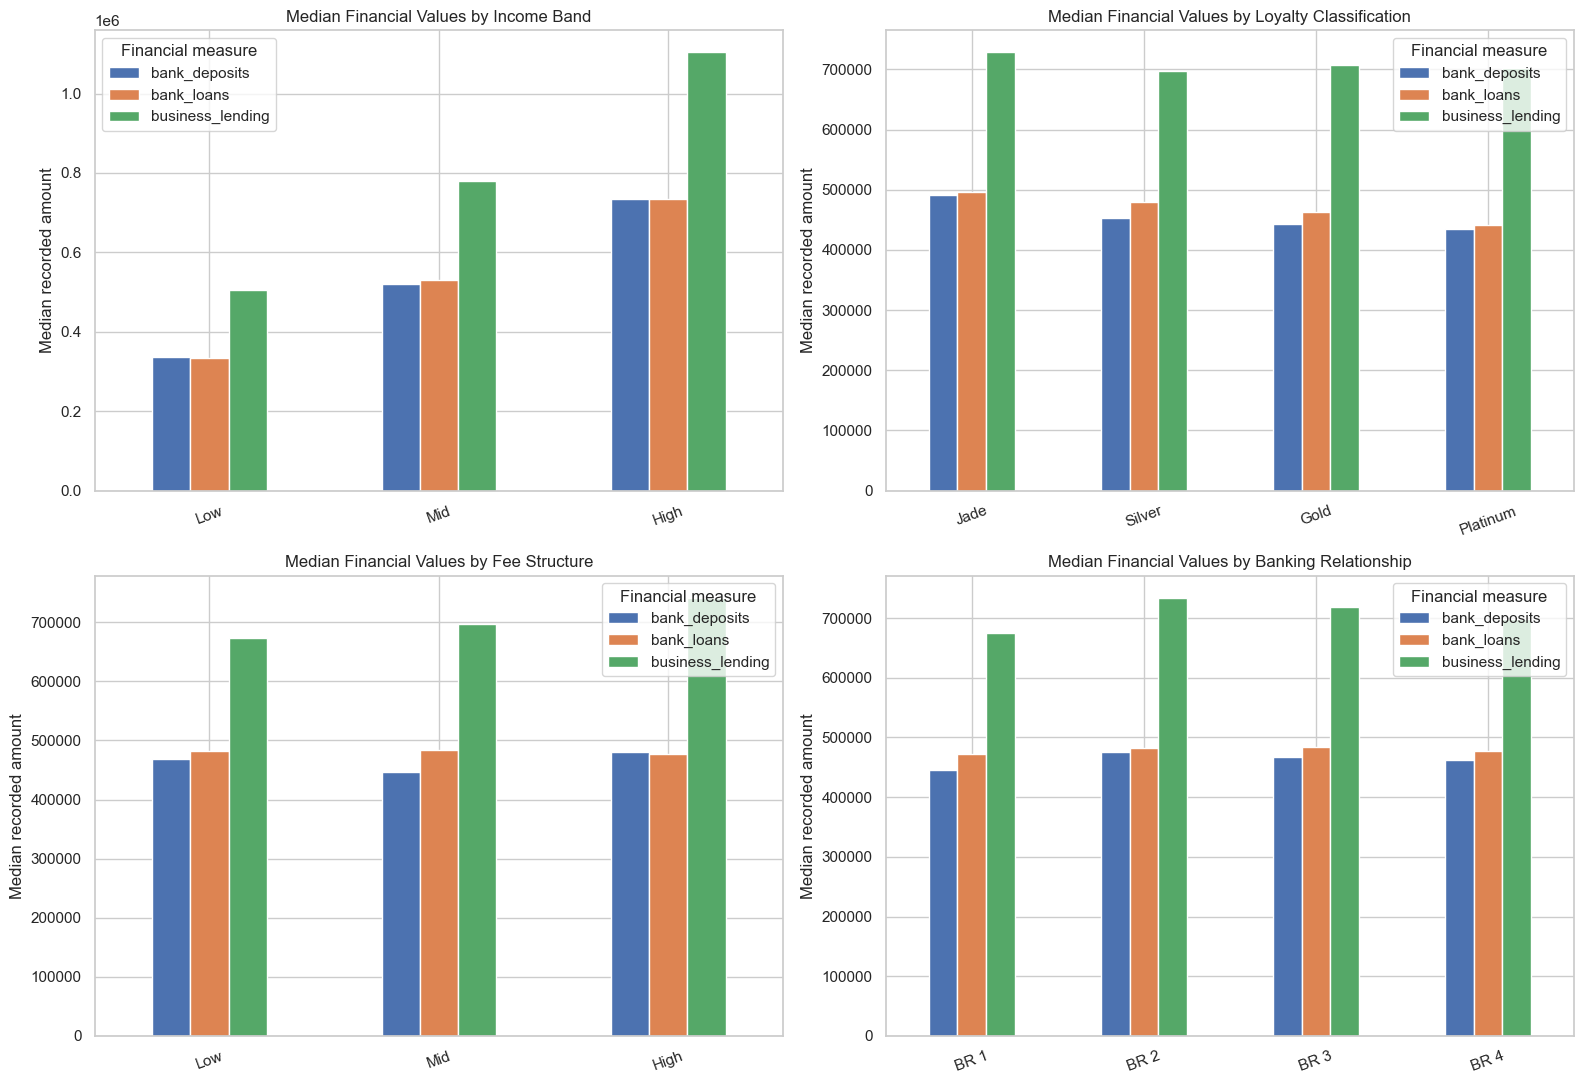

In [21]:
# Calculate median values for each customer group.
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for index, (segment_column, segment_table) in enumerate(
    financial_segment_tables.items()
):
    segment_table.plot(kind="bar", ax=axes[index])
    axes[index].set_title(
        f"Median Financial Values by {segment_column.replace('_', ' ').title()}"
    )
    axes[index].set_xlabel("")
    axes[index].set_ylabel("Median recorded amount")
    axes[index].tick_params(axis="x", rotation=20)
    axes[index].legend(title="Financial measure")
plt.tight_layout()

fig.savefig(
    figures_dir / "median_exposure_by_segment.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 6. Correlation Analysis

Pearson shows linear association, while Spearman compares ranks and is useful for skewed data. Neither one proves cause and effect.

In [22]:
# List the financial columns used in this notebook.
pearson_correlation = df[financial_columns].corr(method="pearson")
spearman_correlation = df[financial_columns].corr(method="spearman")
print("Pearson correlation")
display(pearson_correlation)
print("Spearman correlation")
display(spearman_correlation)

Pearson correlation


,estimated_income,superannuation_savings,credit_card_balance,bank_loans,bank_deposits,checking_accounts,saving_accounts,foreign_currency_account,business_lending
estimated_income,1.00,0.37,0.30,0.33,0.26,0.29,0.26,0.31,0.33
superannuation_savings,0.37,1.00,0.23,0.24,0.17,0.20,0.18,0.23,0.26
credit_card_balance,0.30,0.23,1.00,0.37,0.38,0.30,0.28,0.36,0.35
bank_loans,0.33,0.24,0.37,1.00,0.37,0.29,0.27,0.36,0.42
bank_deposits,0.26,0.17,0.38,0.37,1.00,0.84,0.75,0.41,0.44
checking_accounts,0.29,0.20,0.30,0.29,0.84,1.00,0.46,0.31,0.36
saving_accounts,0.26,0.18,0.28,0.27,0.75,0.46,1.00,0.31,0.31
foreign_currency_account,0.31,0.23,0.36,0.36,0.41,0.31,0.31,1.00,0.37
business_lending,0.33,0.26,0.35,0.42,0.44,0.36,0.31,0.37,1.00


Spearman correlation


,estimated_income,superannuation_savings,credit_card_balance,bank_loans,bank_deposits,checking_accounts,saving_accounts,foreign_currency_account,business_lending
estimated_income,1.00,0.37,0.27,0.30,0.26,0.30,0.27,0.27,0.33
superannuation_savings,0.37,1.00,0.19,0.22,0.15,0.19,0.15,0.21,0.24
credit_card_balance,0.27,0.19,1.00,0.30,0.35,0.27,0.25,0.29,0.30
bank_loans,0.30,0.22,0.30,1.00,0.36,0.27,0.25,0.32,0.36
bank_deposits,0.26,0.15,0.35,0.36,1.00,0.88,0.82,0.36,0.42
checking_accounts,0.30,0.19,0.27,0.27,0.88,1.00,0.64,0.27,0.32
saving_accounts,0.27,0.15,0.25,0.25,0.82,0.64,1.00,0.27,0.30
foreign_currency_account,0.27,0.21,0.29,0.32,0.36,0.27,0.27,1.00,0.34
business_lending,0.33,0.24,0.30,0.36,0.42,0.32,0.30,0.34,1.00


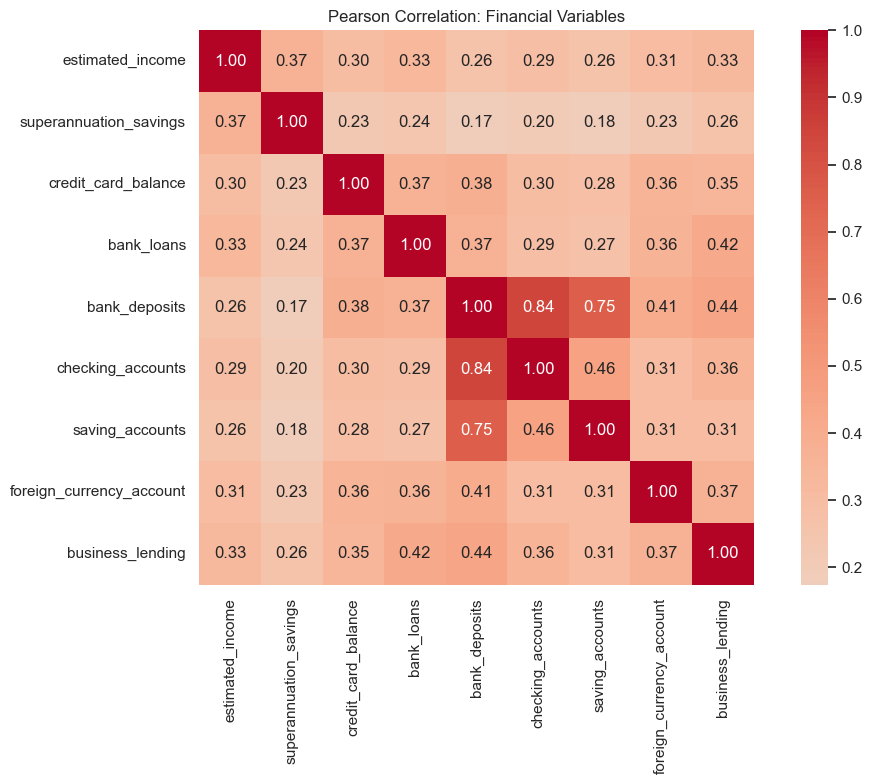

In [23]:
# Calculate Pearson and Spearman correlations.
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    pearson_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax,
)
ax.set_title("Pearson Correlation: Financial Variables")
plt.tight_layout()

fig.savefig(
    figures_dir / "pearson_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

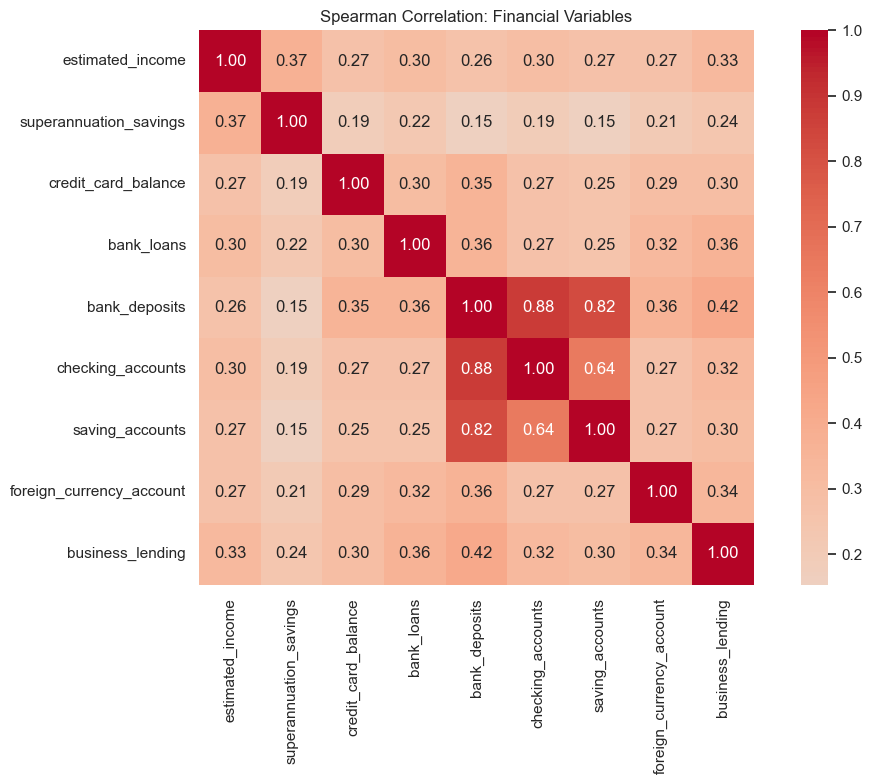

In [24]:
# Create and save the Spearman heatmap.
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    spearman_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax,
)
ax.set_title("Spearman Correlation: Financial Variables")
plt.tight_layout()

fig.savefig(
    figures_dir / "spearman_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [25]:
# Build the table of unique correlation pairs.
correlation_rows = []

In [26]:
# List the financial columns used in this notebook.
for first_index, first_column in enumerate(financial_columns):
    for second_column in financial_columns[first_index + 1 :]:
        correlation_rows.append(
            {
                "variable_1": first_column,
                "variable_2": second_column,
                "pearson_correlation": pearson_correlation.loc[
                    first_column, second_column
                ],
                "spearman_correlation": spearman_correlation.loc[
                    first_column, second_column
                ],
            }
        )

In [27]:
# Calculate Pearson and Spearman correlations.
correlation_summary = pd.DataFrame(correlation_rows)
correlation_summary["absolute_pearson"] = correlation_summary[
    "pearson_correlation"
].abs()
correlation_summary["absolute_spearman"] = correlation_summary[
    "spearman_correlation"
].abs()
correlation_summary = correlation_summary.sort_values(
    "absolute_spearman",
    ascending=False,
)
print("Strongest financial correlations")

Strongest financial correlations


**Observation:** Bank deposits has the strongest relationships with checking accounts (Pearson **0.844**, Spearman **0.880**) and saving accounts (Pearson **0.755**, Spearman **0.824**). These fields may overlap operationally, so they must not be summed without business confirmation.

In [28]:
# Run this step and check the result.
display(correlation_summary.head(10))

,variable_1,variable_2,pearson_correlation,spearman_correlation,absolute_pearson,absolute_spearman
26,bank_deposits,checking_accounts,0.84,0.88,0.84,0.88
27,bank_deposits,saving_accounts,0.75,0.82,0.75,0.82
30,checking_accounts,saving_accounts,0.46,0.64,0.46,0.64
29,bank_deposits,business_lending,0.44,0.42,0.44,0.42
0,estimated_income,superannuation_savings,0.37,0.37,0.37,0.37
25,bank_loans,business_lending,0.42,0.36,0.42,0.36
28,bank_deposits,foreign_currency_account,0.41,0.36,0.41,0.36
21,bank_loans,bank_deposits,0.37,0.36,0.37,0.36
16,credit_card_balance,bank_deposits,0.38,0.35,0.38,0.35
35,foreign_currency_account,business_lending,0.37,0.34,0.37,0.34


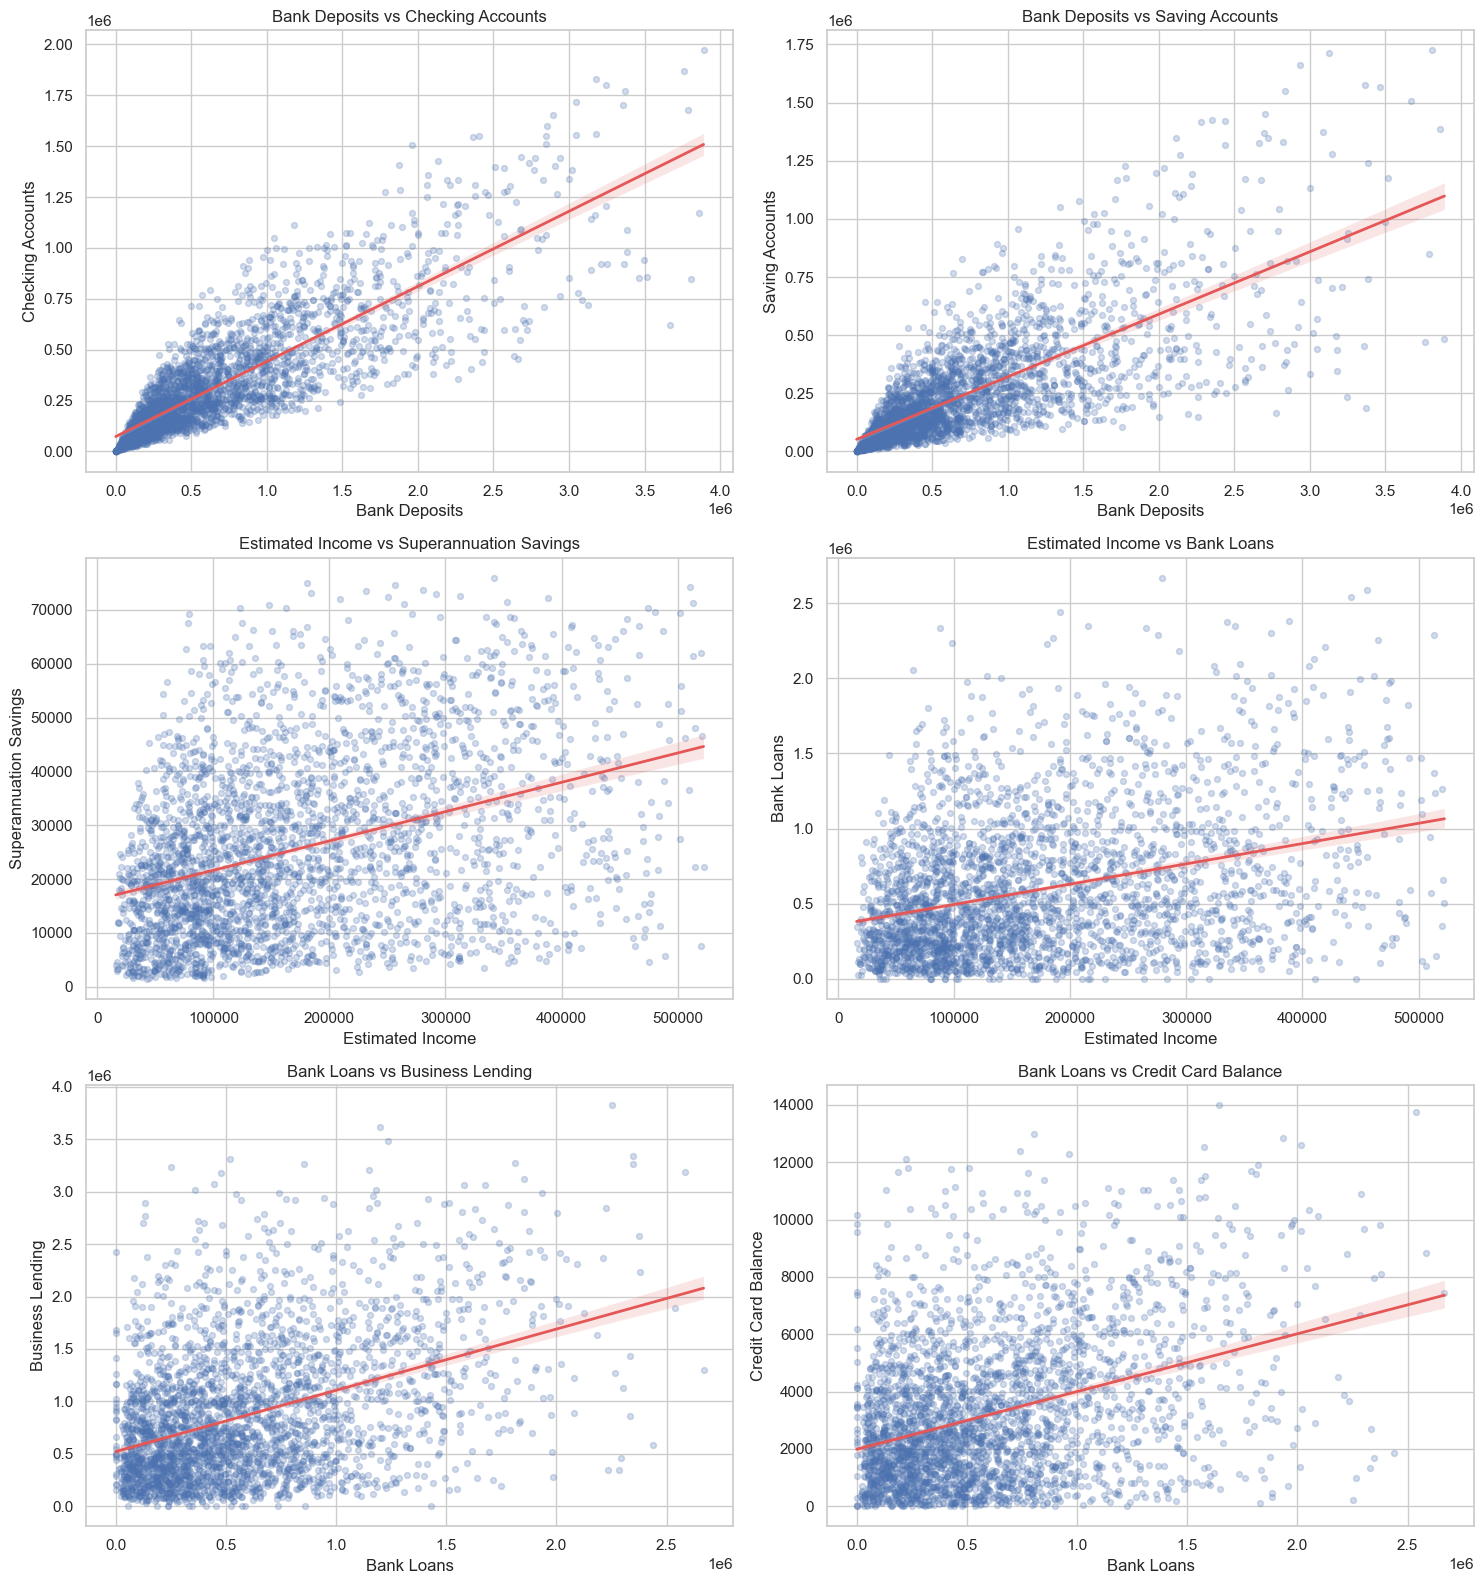

In [29]:
# Create and save the selected scatter plots.
scatter_pairs = [
    ("bank_deposits", "checking_accounts"),
    ("bank_deposits", "saving_accounts"),
    ("estimated_income", "superannuation_savings"),
    ("estimated_income", "bank_loans"),
    ("bank_loans", "business_lending"),
    ("bank_loans", "credit_card_balance"),
]
fig, axes = plt.subplots(3, 2, figsize=(15, 16))
axes = axes.flatten()

for index, (x_column, y_column) in enumerate(scatter_pairs):
    sns.regplot(
        data=df,
        x=x_column,
        y=y_column,
        scatter_kws={"alpha": 0.25, "s": 18},
        line_kws={"color": "#E45756", "linewidth": 2},
        ax=axes[index],
    )
    axes[index].set_title(
        f"{x_column.replace('_', ' ').title()} vs "
        f"{y_column.replace('_', ' ').title()}"
    )
    axes[index].set_xlabel(x_column.replace("_", " ").title())
    axes[index].set_ylabel(y_column.replace("_", " ").title())

plt.tight_layout()
fig.savefig(
    figures_dir / "selected_financial_relationships.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

**Observation:** The selected plots show positive but varying associations. For example, bank loans and business lending have Pearson correlation **0.417**. Trend lines summarize association only and do not demonstrate a causal lending relationship.

## 7. Recorded Risk-Weighting Analysis

I treat `risk_weighting` as an ordered recorded field. Its business direction is not provided, and the dataset has no default or repayment outcome.

In [30]:
# Calculate the risk-weight counts, percentages, and medians.
risk_weighting_summary = (
    df["risk_weighting"]
    .value_counts()
    .reindex(risk_order, fill_value=0)
    .rename_axis("risk_weighting")
    .reset_index(name="customer_count")
)
risk_weighting_summary["percentage"] = (
    risk_weighting_summary["customer_count"] / len(df) * 100
)

In [31]:
# Run this step and check the result.
risk_medians = (
    df.groupby("risk_weighting")[
        [
            "estimated_income",
            "bank_deposits",
            "bank_loans",
            "business_lending",
        ]
    ]
    .median()
    .reindex(risk_order)
    .reset_index()
)

In [32]:
# Calculate the risk-weight counts, percentages, and medians.
risk_weighting_summary = risk_weighting_summary.merge(
    risk_medians,
    on="risk_weighting",
    how="left",
)
display(risk_weighting_summary)

,risk_weighting,customer_count,percentage,estimated_income,bank_deposits,bank_loans,business_lending
0,1,836,27.87,"74,861.84","273,727.18","284,473.14","427,343.76"
1,2,1222,40.73,"151,522.07","462,855.36","510,263.73","766,480.59"
2,3,460,15.33,"256,053.66","641,371.47","714,279.45","1,014,721.06"
3,4,322,10.73,"289,627.09","807,667.70","745,409.97","1,089,013.76"
4,5,160,5.33,"311,787.78","849,056.03","908,902.09","1,151,318.82"


**Observation:** Recorded weights 1 and 2 contain **68.6%** of customer records. Median estimated income rises from **74,861.84** at weight 1 to **311,787.78** at weight 5, but the business direction of the ordinal field is unverified.

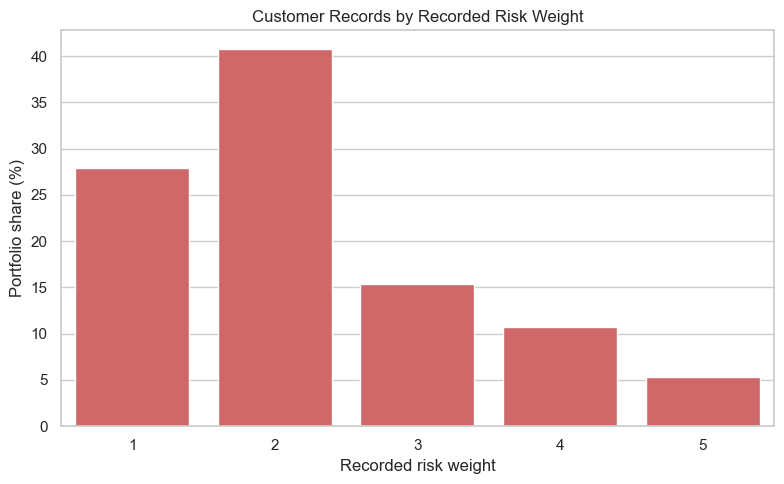

In [33]:
# Calculate the risk-weight counts, percentages, and medians.
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=risk_weighting_summary,
    x="risk_weighting",
    y="percentage",
    order=risk_order,
    color="#E15759",
    ax=ax,
)

ax.set(
    title="Customer Records by Recorded Risk Weight",
    xlabel="Recorded risk weight",
    ylabel="Portfolio share (%)",
)
plt.tight_layout()
fig.savefig(
    figures_dir / "risk_weighting_percentage.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

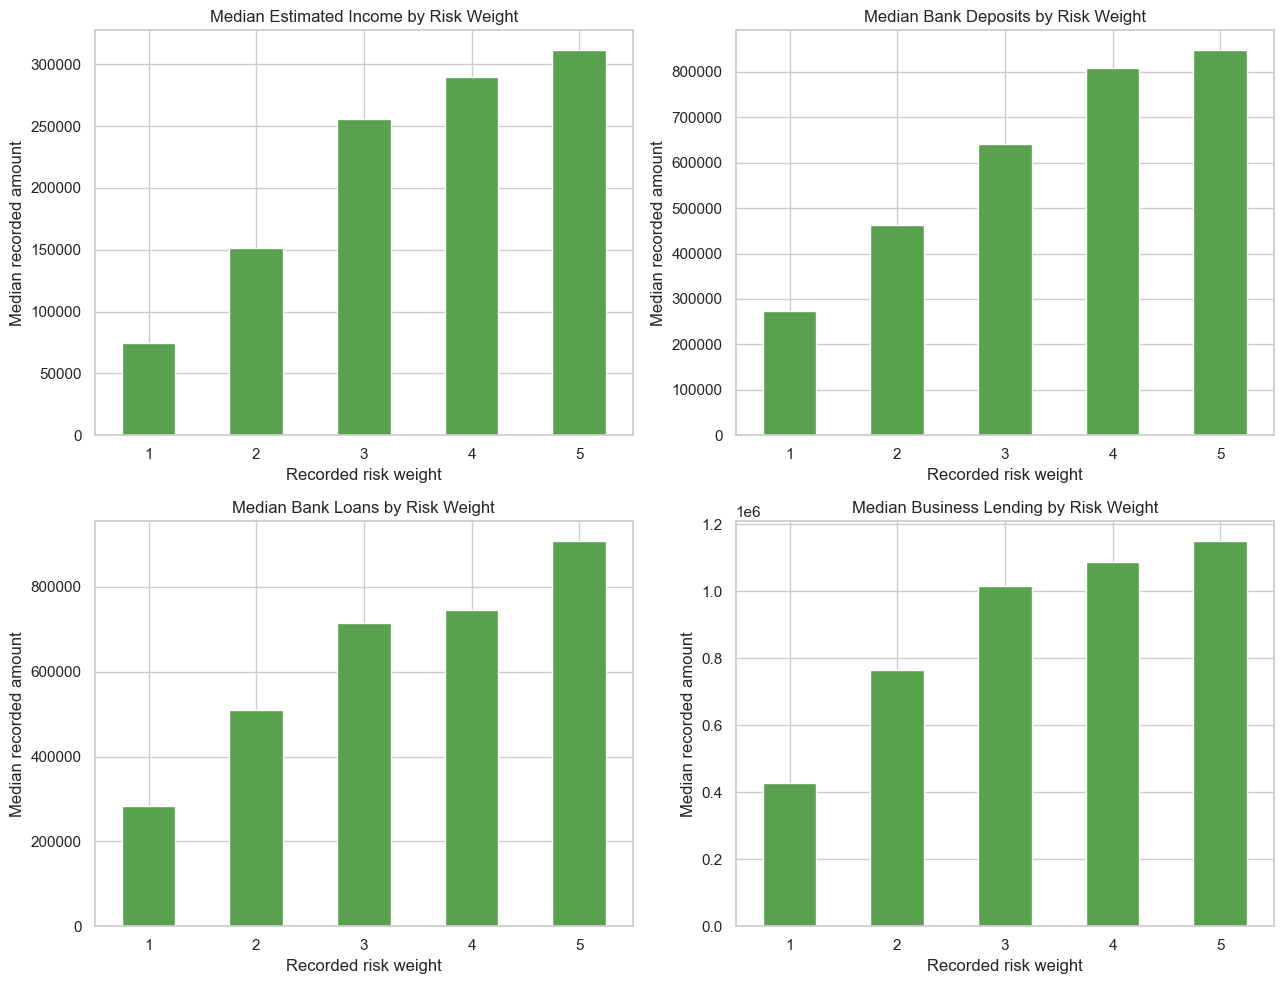

In [34]:
# Calculate the risk-weight counts, percentages, and medians.
risk_plot_data = risk_weighting_summary.set_index("risk_weighting")[
    [
        "estimated_income",
        "bank_deposits",
        "bank_loans",
        "business_lending",
    ]
]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for index, column in enumerate(risk_plot_data.columns):
    risk_plot_data[column].plot(
        kind="bar",
        color="#59A14F",
        ax=axes[index],
    )
    axes[index].set_title(
        f"Median {column.replace('_', ' ').title()} by Risk Weight"
    )
    axes[index].set_xlabel("Recorded risk weight")
    axes[index].set_ylabel("Median recorded amount")
    axes[index].tick_params(axis="x", rotation=0)

plt.tight_layout()
fig.savefig(
    figures_dir / "risk_weighting_financial_medians.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [35]:
# Calculate normalized risk-weight tables for each group.
risk_by_income = (
    pd.crosstab(
        df["income_band"],
        df["risk_weighting"],
        normalize="index",
    ).reindex(index=income_order, columns=risk_order, fill_value=0)
    * 100
)

In [36]:
# Run this step and check the result.
risk_by_loyalty = (
    pd.crosstab(
        df["loyalty_classification"],
        df["risk_weighting"],
        normalize="index",
    ).reindex(index=loyalty_order, columns=risk_order, fill_value=0)
    * 100
)

In [37]:
# Create neutral BR labels and set the category orders.
risk_by_relationship = (
    pd.crosstab(
        df["banking_relationship"],
        df["risk_weighting"],
        normalize="index",
    ).reindex(index=br_order, columns=risk_order, fill_value=0)
    * 100
)
print("Risk-weight composition within income bands")
display(risk_by_income.round(2))
print("Risk-weight composition within loyalty classifications")
display(risk_by_loyalty.round(2))

Risk-weight composition within income bands


risk_weighting,1,2,3,4,5
income_band,,,,,
Low,60.76,31.55,4.77,2.34,0.58
Mid,13.97,55.50,16.22,9.62,4.68
High,0.00,12.28,36.18,33.33,18.20


Risk-weight composition within loyalty classifications


risk_weighting,1,2,3,4,5
loyalty_classification,,,,,
Jade,26.67,42.37,14.58,11.12,5.26
Silver,28.94,39.24,16.56,9.13,6.13
Gold,27.86,40.51,15.56,11.11,4.96
Platinum,30.28,37.85,15.14,12.30,4.42


**Observation:** Risk composition changes strongly across income bands but only modestly across loyalty and BR groups. For example, **60.8%** of Low-income records have weight 1, while **36.2%** of High-income records have weight 3. This does not mean higher weights represent default risk.

In [38]:
# Run this step and check the result.
print("Risk-weight composition within banking relationships")
display(risk_by_relationship.round(2))

Risk-weight composition within banking relationships


risk_weighting,1,2,3,4,5
banking_relationship,,,,,
BR 1,28.94,41.82,13.18,10.91,5.15
BR 2,26.06,40.61,15.35,12.12,5.86
BR 3,28.85,40.16,15.90,9.62,5.47
BR 4,25.56,40.97,16.63,12.17,4.67


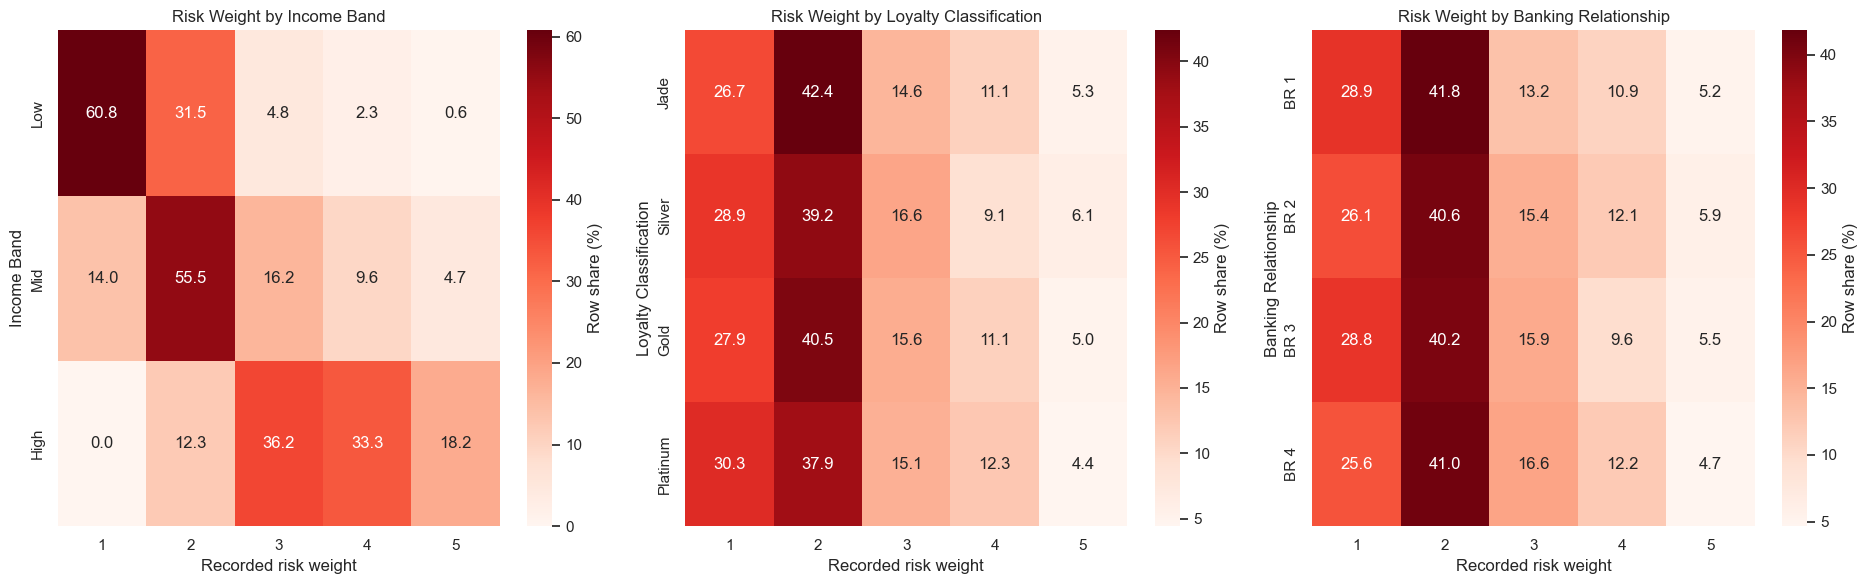

In [39]:
# Calculate normalized risk-weight tables for each group.
risk_segment_tables = {
    "Income Band": risk_by_income,
    "Loyalty Classification": risk_by_loyalty,
    "Banking Relationship": risk_by_relationship,
}
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

for index, (title, table) in enumerate(risk_segment_tables.items()):
    sns.heatmap(
        table,
        annot=True,
        fmt=".1f",
        cmap="Reds",
        cbar_kws={"label": "Row share (%)"},
        ax=axes[index],
    )
    axes[index].set_title(f"Risk Weight by {title}")
    axes[index].set_xlabel("Recorded risk weight")
    axes[index].set_ylabel(title)

plt.tight_layout()
fig.savefig(
    figures_dir / "risk_weighting_segment_heatmaps.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [40]:
# List the financial columns used in this notebook.
risk_spearman = (
    df[["risk_weighting"] + financial_columns]
    .corr(method="spearman")
    .loc["risk_weighting", financial_columns]
    .sort_values(key=abs, ascending=False)
    .rename("spearman_correlation")
    .reset_index()
    .rename(columns={"index": "financial_variable"})
)
display(risk_spearman)

,financial_variable,spearman_correlation
0,estimated_income,0.68
1,superannuation_savings,0.49
2,business_lending,0.42
3,bank_loans,0.40
4,foreign_currency_account,0.39
5,checking_accounts,0.38
6,credit_card_balance,0.37
7,saving_accounts,0.35
8,bank_deposits,0.34


**Observation:** Risk weighting has its strongest financial Spearman association with estimated income (**0.680**). Because no default, repayment, or loss outcome exists, this association cannot be interpreted as default probability or predictive performance.

## Export Analysis Tables

I save the four summary tables used in this notebook.

In [41]:
# Display the financial distribution summary.
financial_distribution_summary.to_csv(
    tables_dir / "financial_distribution_summary.csv",
    index=False,
)
correlation_summary.to_csv(
    tables_dir / "correlation_summary.csv",
    index=False,
)
risk_weighting_summary.to_csv(
    tables_dir / "risk_weighting_summary.csv",
    index=False,
)

In [42]:
# Save the four requested summary tables.
financial_segment_summary.to_csv(
    tables_dir / "financial_segment_summary.csv",
    index=False,
)
print("Four financial-analysis tables exported successfully.")

Four financial-analysis tables exported successfully.


## 8. Final Insights and Limitations

These points summarize the main results.

In [43]:
# Display the financial distribution summary.
most_skewed_row = financial_distribution_summary.sort_values(
    "skewness",
    ascending=False,
).iloc[0]
strongest_pair = correlation_summary.iloc[0]
second_pair = correlation_summary.iloc[1]
low_income_deposits = financial_segment_tables["income_band"].loc[
    "Low", "bank_deposits"
]
high_income_deposits = financial_segment_tables["income_band"].loc[
    "High", "bank_deposits"
]

In [44]:
# Calculate the risk-weight counts, percentages, and medians.
risk_one_share = risk_weighting_summary.loc[
    risk_weighting_summary["risk_weighting"] == 1,
    "percentage",
].iloc[0]
risk_two_share = risk_weighting_summary.loc[
    risk_weighting_summary["risk_weighting"] == 2,
    "percentage",
].iloc[0]
risk_income_spearman = risk_spearman.loc[
    risk_spearman["financial_variable"] == "estimated_income",
    "spearman_correlation",
].iloc[0]

In [45]:
# Calculate the risk-weight counts, percentages, and medians.
risk_one_income = risk_weighting_summary.loc[
    risk_weighting_summary["risk_weighting"] == 1,
    "estimated_income",
].iloc[0]
risk_five_income = risk_weighting_summary.loc[
    risk_weighting_summary["risk_weighting"] == 5,
    "estimated_income",
].iloc[0]

In [46]:
# Collect the values used in the final insights.
insights = [
    f"1. **Distribution shape:** {most_skewed_row['financial_variable'].replace('_', ' ').title()} is the most skewed variable at {most_skewed_row['skewness']:.3f}, with {most_skewed_row['potential_outlier_percentage']:.2f}% potential IQR outliers. These values are flags, not confirmed errors.",
    f"2. **Deposit centre:** Median bank deposits are {df['bank_deposits'].median():,.2f}, below the mean of {df['bank_deposits'].mean():,.2f}. This indicates right skew, but currency units and valuation dates are not documented.",
    f"3. **Strongest relationship:** {strongest_pair['variable_1'].replace('_', ' ').title()} and {strongest_pair['variable_2'].replace('_', ' ').title()} have Pearson {strongest_pair['pearson_correlation']:.3f} and Spearman {strongest_pair['spearman_correlation']:.3f}. Strong association does not prove causation or that the fields are independent balances.",
    f"4. **Second relationship:** {second_pair['variable_1'].replace('_', ' ').title()} and {second_pair['variable_2'].replace('_', ' ').title()} have Spearman {second_pair['spearman_correlation']:.3f}. Their business relationship may overlap and must be confirmed before aggregation.",
    f"5. **Income-band exposure:** Median deposits rise from {low_income_deposits:,.2f} in Low income to {high_income_deposits:,.2f} in High income. Income bands are project-specific and the comparison is descriptive, not causal.",
    f"6. **Risk-weight concentration:** Recorded weights 1 and 2 account for {risk_one_share + risk_two_share:.1f}% of records. The codes are ordinal, but their exact risk direction is not documented.",
    f"7. **Risk weight and income:** Spearman correlation between risk weighting and estimated income is {risk_income_spearman:.3f}; median income moves from {risk_one_income:,.2f} at weight 1 to {risk_five_income:,.2f} at weight 5. This does not show default probability or causal risk.",
    f"8. **High-value records:** {int(financial_distribution_summary['potential_outlier_count'].max())} potential outliers occur in the most frequently flagged financial field. No values are removed because high balances may represent genuine customers.",
]
display(Markdown("<br><br>".join(insights)))

1. **Distribution shape:** Saving Accounts is the most skewed variable at 2.193, with 5.17% potential IQR outliers. These values are flags, not confirmed errors.<br><br>2. **Deposit centre:** Median bank deposits are 463,316.46, below the mean of 671,560.19. This indicates right skew, but currency units and valuation dates are not documented.<br><br>3. **Strongest relationship:** Bank Deposits and Checking Accounts have Pearson 0.844 and Spearman 0.880. Strong association does not prove causation or that the fields are independent balances.<br><br>4. **Second relationship:** Bank Deposits and Saving Accounts have Spearman 0.824. Their business relationship may overlap and must be confirmed before aggregation.<br><br>5. **Income-band exposure:** Median deposits rise from 336,806.30 in Low income to 735,655.26 in High income. Income bands are project-specific and the comparison is descriptive, not causal.<br><br>6. **Risk-weight concentration:** Recorded weights 1 and 2 account for 68.6% of records. The codes are ordinal, but their exact risk direction is not documented.<br><br>7. **Risk weight and income:** Spearman correlation between risk weighting and estimated income is 0.680; median income moves from 74,861.84 at weight 1 to 311,787.78 at weight 5. This does not show default probability or causal risk.<br><br>8. **High-value records:** 155 potential outliers occur in the most frequently flagged financial field. No values are removed because high balances may represent genuine customers.

### Remaining limitations

- Currency, financial units, valuation date, and account definitions are not provided.
- Deposit, checking, and saving fields may overlap, so I do not add them together.
- Correlation shows association, not cause and effect.
- IQR outliers are flags, not confirmed errors.
- Repeated client IDs from EDA 1 may affect record-level summaries.
- The direction and business meaning of `risk_weighting` are not confirmed.
- There is no default, repayment, or loss outcome, so this is not a default-prediction analysis.